In [6]:
# Sampling Assignment – Handling Imbalanced Dataset

## Objective
# The objective of this assignment is to understand the importance of sampling techniques in handling imbalanced datasets and to analyze how different sampling strategies affect the accuracy of multiple machine learning models.

# Dataset used: Credit Card Dataset

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler, NearMiss
from imblearn.combine import SMOTEENN

In [8]:
data = pd.read_csv("/content/Creditcard_data.csv")
data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,1
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [9]:
data['Class'].value_counts()

,count
Class,
0,763
1,9


In [10]:
X = data.drop('Class', axis=1)
y = data['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [11]:
sampling_methods = {
    "Random_Undersampling": RandomUnderSampler(random_state=42),
    "Random_Oversampling": RandomOverSampler(random_state=42),
    "SMOTE": SMOTE(random_state=42),
    "NearMiss": NearMiss(),
    "SMOTEENN": SMOTEENN(random_state=42)
}

In [12]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC()
}

In [13]:
results = pd.DataFrame(index=models.keys(), columns=sampling_methods.keys())

for s_name, sampler in sampling_methods.items():
    X_res, y_res = sampler.fit_resample(X_train, y_train)

    for m_name, model in models.items():
        model.fit(X_res, y_res)
        preds = model.predict(X_test)
        acc = accuracy_score(y_test, preds)
        results.loc[m_name, s_name] = round(acc * 100, 2)

results

,Random_Undersampling,Random_Oversampling,SMOTE,NearMiss,SMOTEENN
Logistic Regression,60.0,90.97,92.26,29.03,90.32
Decision Tree,37.42,99.35,98.71,50.97,98.71
Random Forest,63.87,98.71,98.71,15.48,98.71
KNN,69.03,96.77,92.26,97.42,91.61
SVM,52.26,95.48,96.13,30.97,95.48


In [14]:
results

,Random_Undersampling,Random_Oversampling,SMOTE,NearMiss,SMOTEENN
Logistic Regression,60.0,90.97,92.26,29.03,90.32
Decision Tree,37.42,99.35,98.71,50.97,98.71
Random Forest,63.87,98.71,98.71,15.48,98.71
KNN,69.03,96.77,92.26,97.42,91.61
SVM,52.26,95.48,96.13,30.97,95.48


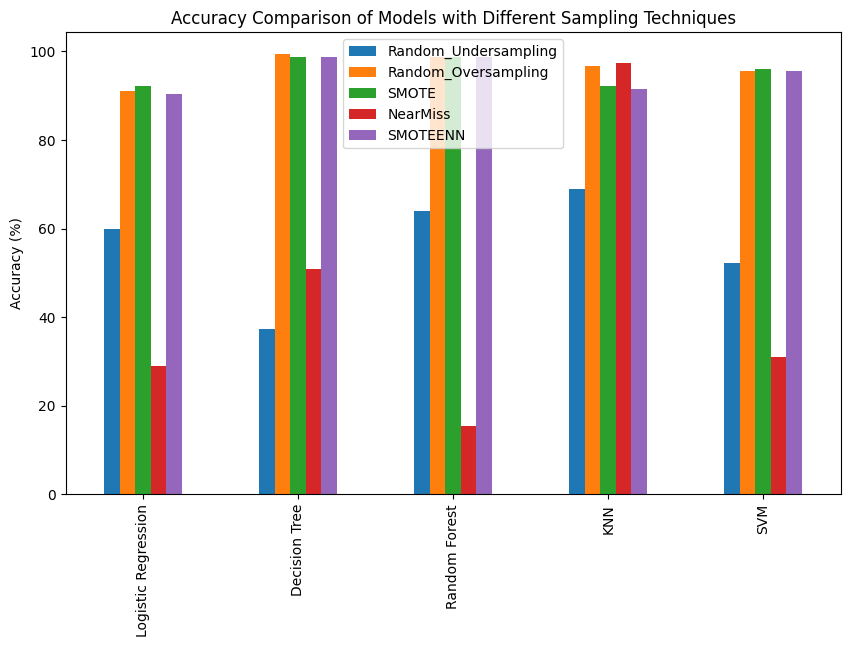

In [15]:
results.astype(float).plot(kind='bar', figsize=(10,6))
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Comparison of Models with Different Sampling Techniques")
plt.show()

In [17]:
## Conclusion

# The results clearly show that different sampling techniques affect machine learning models differently.
# Oversampling methods such as SMOTE and SMOTEENN generally improve performance on imbalanced data,
# while undersampling methods may reduce accuracy for some models.

# There is no single best sampling technique for all models, and the choice of sampling strategy
# should depend on the model and problem requirements.